# 🏠 Real Estate Investment Advisor
## Predicting Property Profitability & Future Value

**Domain:** Real Estate / Investment / Financial Analytics  
**Dataset:** `india_housing_prices.csv` — 250,000 Indian property records  

### Goals
| Task | Target | Method |
|------|--------|---------|
| Classification | Is this a **Good Investment**? | Random Forest, Logistic Regression |
| Regression | **Estimated Price after 5 Years** | Random Forest, Ridge Regression |

---

## Step 1: Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.metrics import (
    accuracy_score, f1_score, confusion_matrix, classification_report,
    mean_squared_error, mean_absolute_error, r2_score
)

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.titlesize'] = 13
sns.set_style('whitegrid')
print('All libraries imported successfully ✓')

All libraries imported successfully ✓


## Step 2: Load Dataset

In [2]:
df = pd.read_csv('india_housing_prices.csv')
print(f'Shape: {df.shape}')
print(f'Rows: {df.shape[0]:,}  |  Columns: {df.shape[1]}')
df.head()

Shape: (250000, 23)
Rows: 250,000  |  Columns: 23


,ID,State,City,Locality,Property_Type,BHK,Size_in_SqFt,Price_in_Lakhs,Price_per_SqFt,Year_Built,...,Age_of_Property,Nearby_Schools,Nearby_Hospitals,Public_Transport_Accessibility,Parking_Space,Security,Amenities,Facing,Owner_Type,Availability_Status
0,1,Tamil Nadu,Chennai,Locality_84,Apartment,1,4740,489.76,0.10,1990,...,35,10,3,High,No,No,"Playground, Gym, Garden, Pool, Clubhouse",West,Owner,Ready_to_Move
1,2,Maharashtra,Pune,Locality_490,Independent House,3,2364,195.52,0.08,2008,...,17,8,1,Low,No,Yes,"Playground, Clubhouse, Pool, Gym, Garden",North,Builder,Under_Construction
2,3,Punjab,Ludhiana,Locality_167,Apartment,2,3642,183.79,0.05,1997,...,28,9,8,Low,Yes,No,"Clubhouse, Pool, Playground, Gym",South,Broker,Ready_to_Move
3,4,Rajasthan,Jodhpur,Locality_393,Independent House,2,2741,300.29,0.11,1991,...,34,5,7,High,Yes,Yes,"Playground, Clubhouse, Gym, Pool, Garden",North,Builder,Ready_to_Move
4,5,Rajasthan,Jaipur,Locality_466,Villa,4,4823,182.90,0.04,2002,...,23,4,9,Low,No,Yes,"Playground, Garden, Gym, Pool, Clubhouse",East,Builder,Ready_to_Move


In [3]:
print('\n--- Data Types ---')
print(df.dtypes)
print(f'\nMissing values: {df.isnull().sum().sum()}')
print(f'Duplicate rows: {df.duplicated().sum()}')


--- Data Types ---
ID                                  int64
State                              object
City                               object
Locality                           object
Property_Type                      object
BHK                                 int64
Size_in_SqFt                        int64
Price_in_Lakhs                    float64
Price_per_SqFt                    float64
Year_Built                          int64
Furnished_Status                   object
Floor_No                            int64
Total_Floors                        int64
Age_of_Property                     int64
Nearby_Schools                      int64
Nearby_Hospitals                    int64
Public_Transport_Accessibility     object
Parking_Space                      object
Security                           object
Amenities                          object
Facing                             object
Owner_Type                         object
Availability_Status                object
dtype: object


In [4]:
df.describe()

,ID,BHK,Size_in_SqFt,Price_in_Lakhs,Price_per_SqFt,Year_Built,Floor_No,Total_Floors,Age_of_Property,Nearby_Schools,Nearby_Hospitals
count,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000
mean,125000.500000,2.999396,2749.813216,254.586854,0.130597,2006.520012,14.966800,15.503004,18.479988,5.499860,5.498016
std,72168.927986,1.415521,1300.606954,141.349921,0.130747,9.808575,8.948047,8.671618,9.808575,2.878639,2.871860
min,1.000000,1.000000,500.000000,10.000000,0.000000,1990.000000,0.000000,1.000000,2.000000,1.000000,1.000000
25%,62500.750000,2.000000,1623.000000,132.550000,0.050000,1998.000000,7.000000,8.000000,10.000000,3.000000,3.000000
50%,125000.500000,3.000000,2747.000000,253.870000,0.090000,2007.000000,15.000000,15.000000,18.000000,5.000000,5.000000
75%,187500.250000,4.000000,3874.000000,376.880000,0.160000,2015.000000,23.000000,23.000000,27.000000,8.000000,8.000000
max,250000.000000,5.000000,5000.000000,500.000000,0.990000,2023.000000,30.000000,30.000000,35.000000,10.000000,10.000000


## Step 3: Data Preprocessing

- Remove duplicates  
- Encode binary Yes/No columns  
- No missing values found in this dataset

In [24]:
df.drop_duplicates(inplace=True)

# Encode binary columns
df['Parking_Space'] = (df['Parking_Space'] == 'Yes').astype(int)
df['Security']      = (df['Security']      == 'Yes').astype(int)

print(f'Dataset after cleaning: {df.shape}')
print(f'Parking_Space values: {df["Parking_Space"].value_counts().to_dict()}')
print(f'Security values     : {df["Security"].value_counts().to_dict()}')

Dataset after cleaning: (250000, 29)
Parking_Space values: {0: 250000}
Security values     : {0: 250000}


## Step 4: Feature Engineering

| New Feature | Formula / Rule |
|---|---|
| `Future_Price_5yr` | `Price × (1.08)^5` (8% annual growth) |
| `Calc_Price_per_SqFt` | `Price / Size_in_SqFt` |
| `School_Density_Score` | Normalised nearby schools count |
| `Hospital_Density_Score` | Normalised nearby hospitals count |
| `Floor_Ratio` | `Floor_No / Total_Floors` |
| `Good_Investment` | Multi-factor score ≥ 4 → 1 (Good), else 0 |

In [25]:
GROWTH_RATE = 0.08
YEARS = 5

df['Future_Price_5yr']       = df['Price_in_Lakhs'] * ((1 + GROWTH_RATE) ** YEARS)
df['Calc_Price_per_SqFt']    = df['Price_in_Lakhs'] / df['Size_in_SqFt']
df['School_Density_Score']   = df['Nearby_Schools']   / (df['Nearby_Schools'].max()   + 1)
df['Hospital_Density_Score'] = df['Nearby_Hospitals'] / (df['Nearby_Hospitals'].max() + 1)
df['Floor_Ratio']            = df['Floor_No'] / (df['Total_Floors'] + 1)

# Good Investment Label — multi-factor scoring
score = (
    (df['Price_in_Lakhs']                 <= df['Price_in_Lakhs'].median()).astype(int) +
    (df['Calc_Price_per_SqFt']            <= df['Calc_Price_per_SqFt'].median()).astype(int) +
    (df['BHK']                            >= 3).astype(int) +
    (df['Availability_Status']            == 'Ready_to_Move').astype(int) +
    (df['Nearby_Schools']                 >= df['Nearby_Schools'].median()).astype(int) +
    (df['Nearby_Hospitals']               >= df['Nearby_Hospitals'].median()).astype(int) +
    (df['Public_Transport_Accessibility'] == 'High').astype(int)
)
df['Good_Investment'] = (score >= 4).astype(int)

print(f'Good Investment distribution:')
print(df['Good_Investment'].value_counts())
print(f'\nGood Investment %: {df["Good_Investment"].mean()*100:.1f}%')
print(f'Avg Future Price (5yr): ₹{df["Future_Price_5yr"].mean():.2f} Lakhs')

Good Investment distribution:
Good_Investment
1    134349
0    115651
Name: count, dtype: int64

Good Investment %: 53.7%
Avg Future Price (5yr): ₹374.07 Lakhs


## Step 5: Exploratory Data Analysis (EDA)

### 5.1 Price & Size Distributions

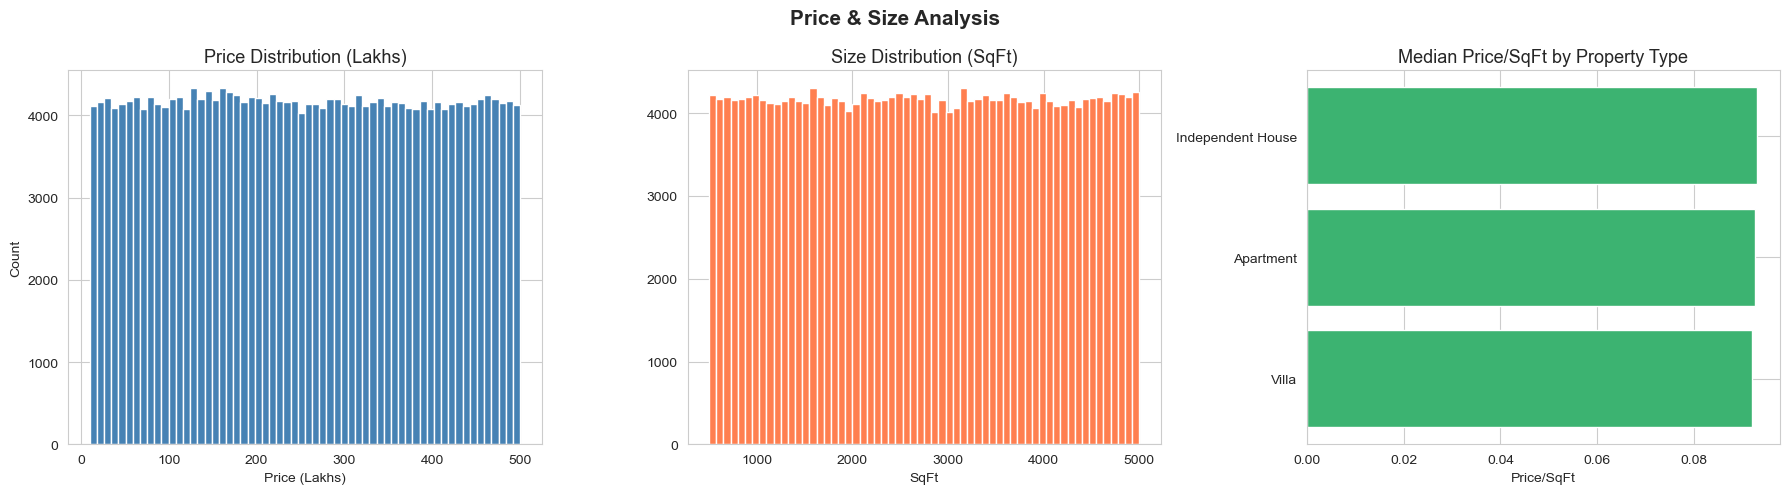

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Price & Size Analysis', fontsize=15, fontweight='bold')

axes[0].hist(df['Price_in_Lakhs'], bins=60, color='steelblue', edgecolor='white')
axes[0].set_title('Price Distribution (Lakhs)')
axes[0].set_xlabel('Price (Lakhs)'); axes[0].set_ylabel('Count')

axes[1].hist(df['Size_in_SqFt'], bins=60, color='coral', edgecolor='white')
axes[1].set_title('Size Distribution (SqFt)')
axes[1].set_xlabel('SqFt')

ptype = df.groupby('Property_Type')['Calc_Price_per_SqFt'].median().sort_values()
axes[2].barh(ptype.index, ptype.values, color='mediumseagreen')
axes[2].set_title('Median Price/SqFt by Property Type')
axes[2].set_xlabel('Price/SqFt')

plt.tight_layout()
plt.show()

### 5.2 Outlier Detection

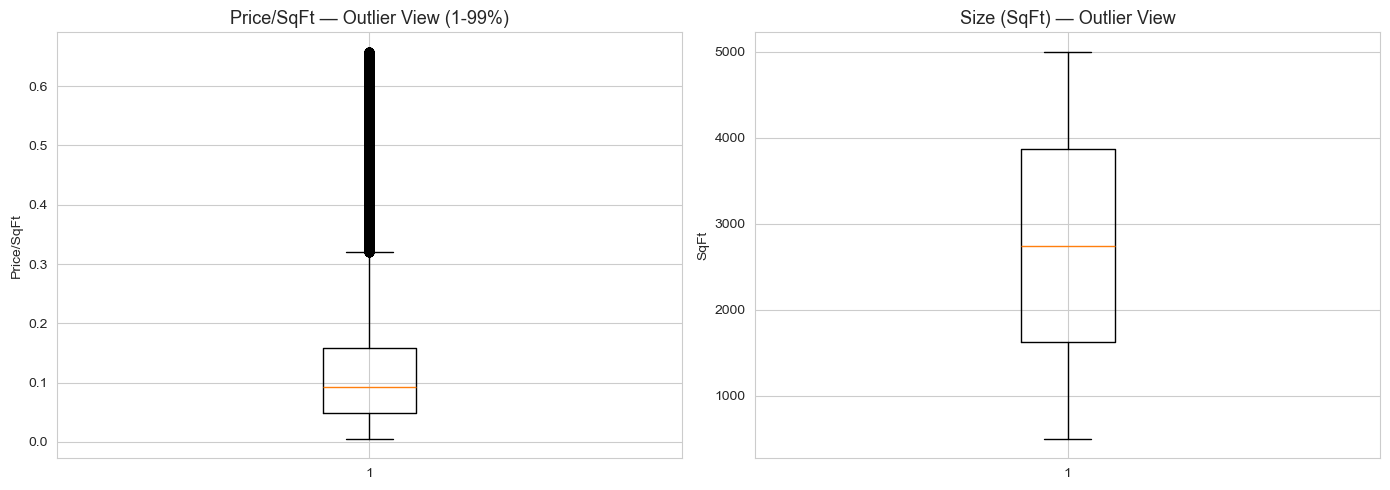

Price/SqFt 1%-99% range: 0.0050 — 0.6582


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

q1, q99 = df['Calc_Price_per_SqFt'].quantile(0.01), df['Calc_Price_per_SqFt'].quantile(0.99)
clean = df[(df['Calc_Price_per_SqFt'] >= q1) & (df['Calc_Price_per_SqFt'] <= q99)]

axes[0].boxplot(clean['Calc_Price_per_SqFt'])
axes[0].set_title('Price/SqFt — Outlier View (1-99%)')
axes[0].set_ylabel('Price/SqFt')

axes[1].boxplot(df['Size_in_SqFt'])
axes[1].set_title('Size (SqFt) — Outlier View')
axes[1].set_ylabel('SqFt')

plt.tight_layout()
plt.show()
print(f'Price/SqFt 1%-99% range: {q1:.4f} — {q99:.4f}')

### 5.3 Location-Based Analysis

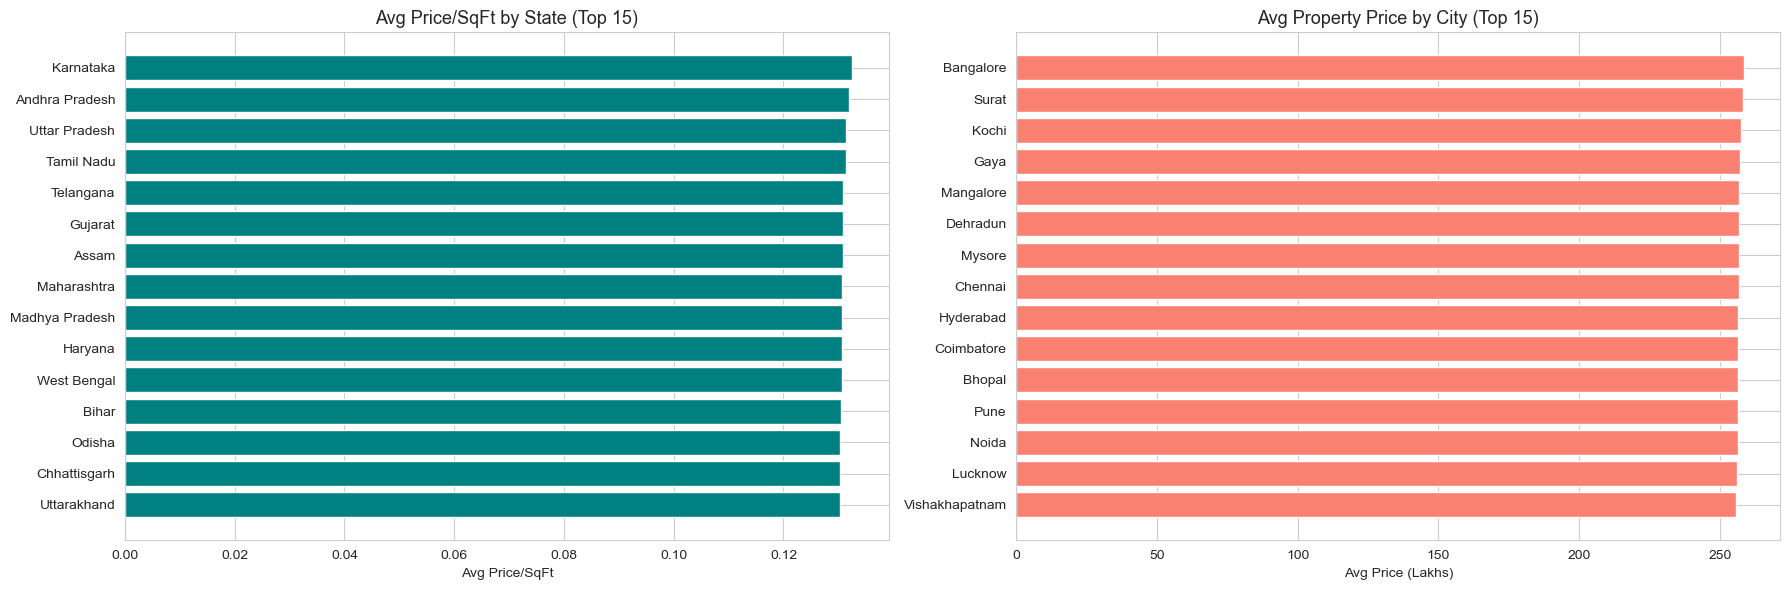

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

sp = df.groupby('State')['Calc_Price_per_SqFt'].mean().sort_values(ascending=False).head(15)
axes[0].barh(sp.index[::-1], sp.values[::-1], color='teal')
axes[0].set_title('Avg Price/SqFt by State (Top 15)')
axes[0].set_xlabel('Avg Price/SqFt')

cp = df.groupby('City')['Price_in_Lakhs'].mean().sort_values(ascending=False).head(15)
axes[1].barh(cp.index[::-1], cp.values[::-1], color='salmon')
axes[1].set_title('Avg Property Price by City (Top 15)')
axes[1].set_xlabel('Avg Price (Lakhs)')

plt.tight_layout()
plt.show()

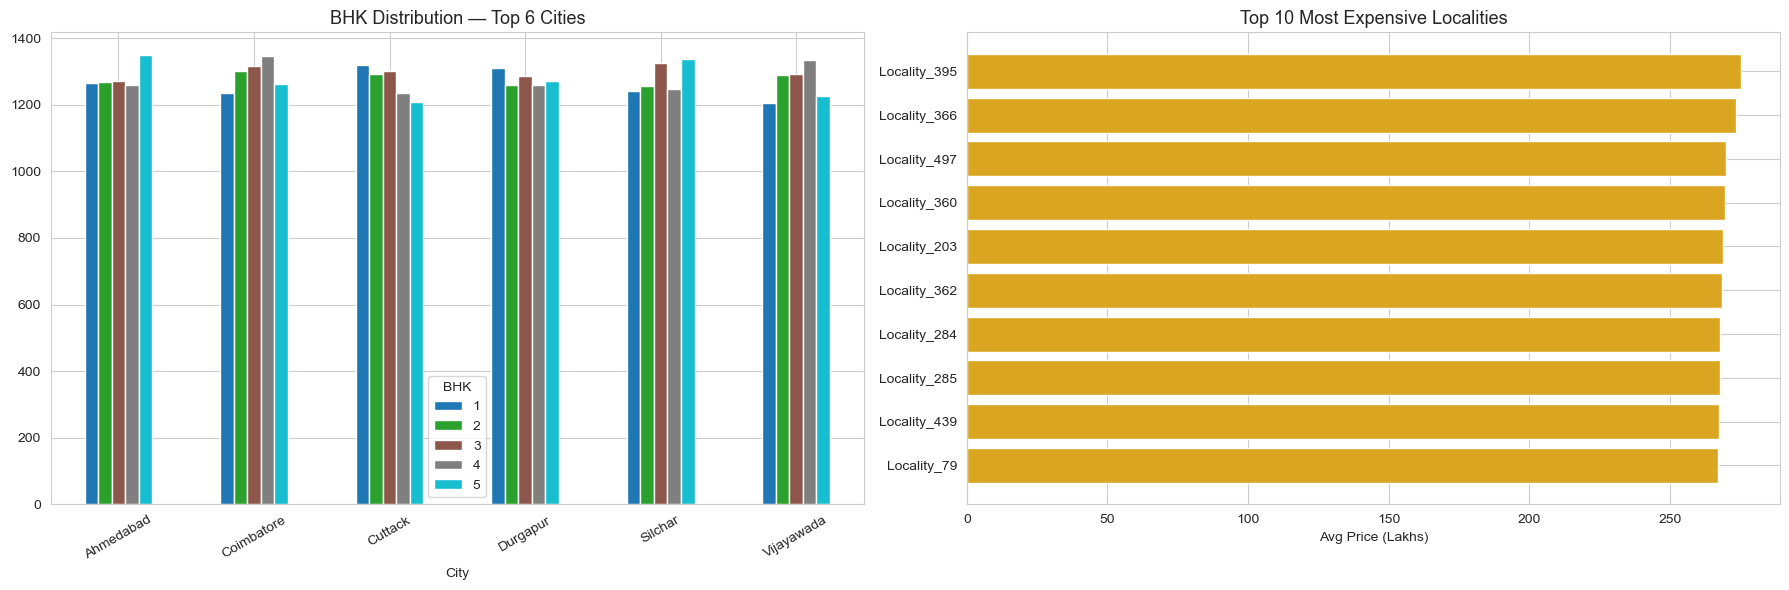

In [10]:
# BHK distribution across top cities
top_cities = df['City'].value_counts().head(6).index
bhk_city = df[df['City'].isin(top_cities)].groupby(['City','BHK']).size().unstack(fill_value=0)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

bhk_city.plot(kind='bar', ax=axes[0], colormap='tab10')
axes[0].set_title('BHK Distribution — Top 6 Cities')
axes[0].set_xlabel('City')
axes[0].tick_params(axis='x', rotation=30)

top_loc = df.groupby('Locality')['Price_in_Lakhs'].mean().sort_values(ascending=False).head(10)
axes[1].barh(top_loc.index[::-1], top_loc.values[::-1], color='goldenrod')
axes[1].set_title('Top 10 Most Expensive Localities')
axes[1].set_xlabel('Avg Price (Lakhs)')

plt.tight_layout()
plt.show()

### 5.4 Correlation Heatmap

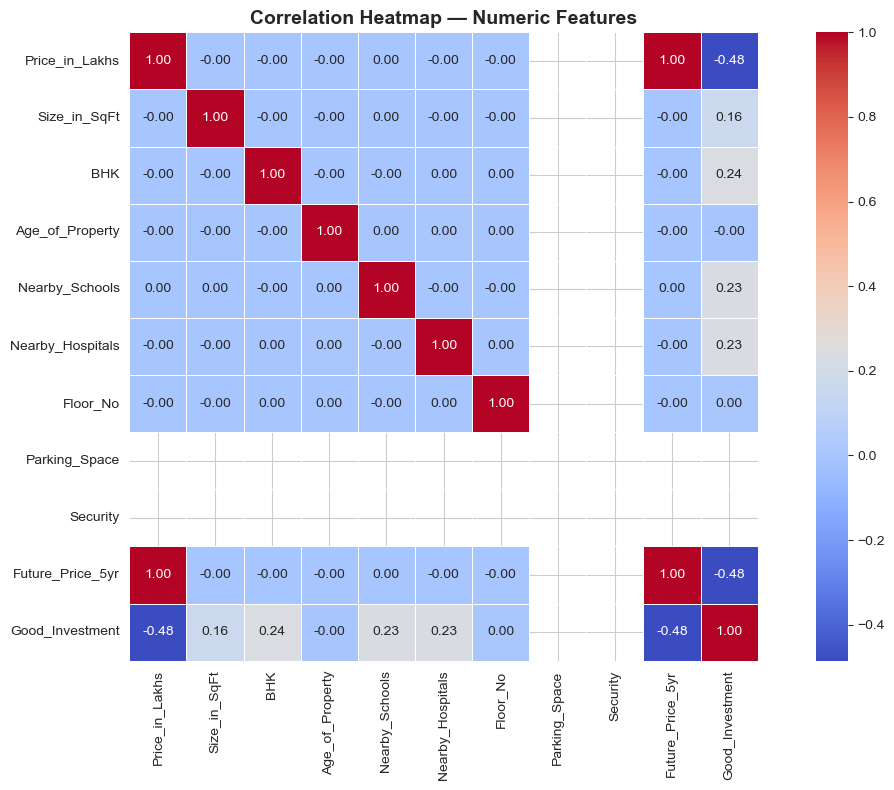

In [26]:
corr_cols = ['Price_in_Lakhs','Size_in_SqFt','BHK','Age_of_Property',
             'Nearby_Schools','Nearby_Hospitals','Floor_No','Parking_Space',
             'Security','Future_Price_5yr','Good_Investment']

plt.figure(figsize=(12, 8))
sns.heatmap(df[corr_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, square=True)
plt.title('Correlation Heatmap — Numeric Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 5.5 Investment & Amenities Analysis

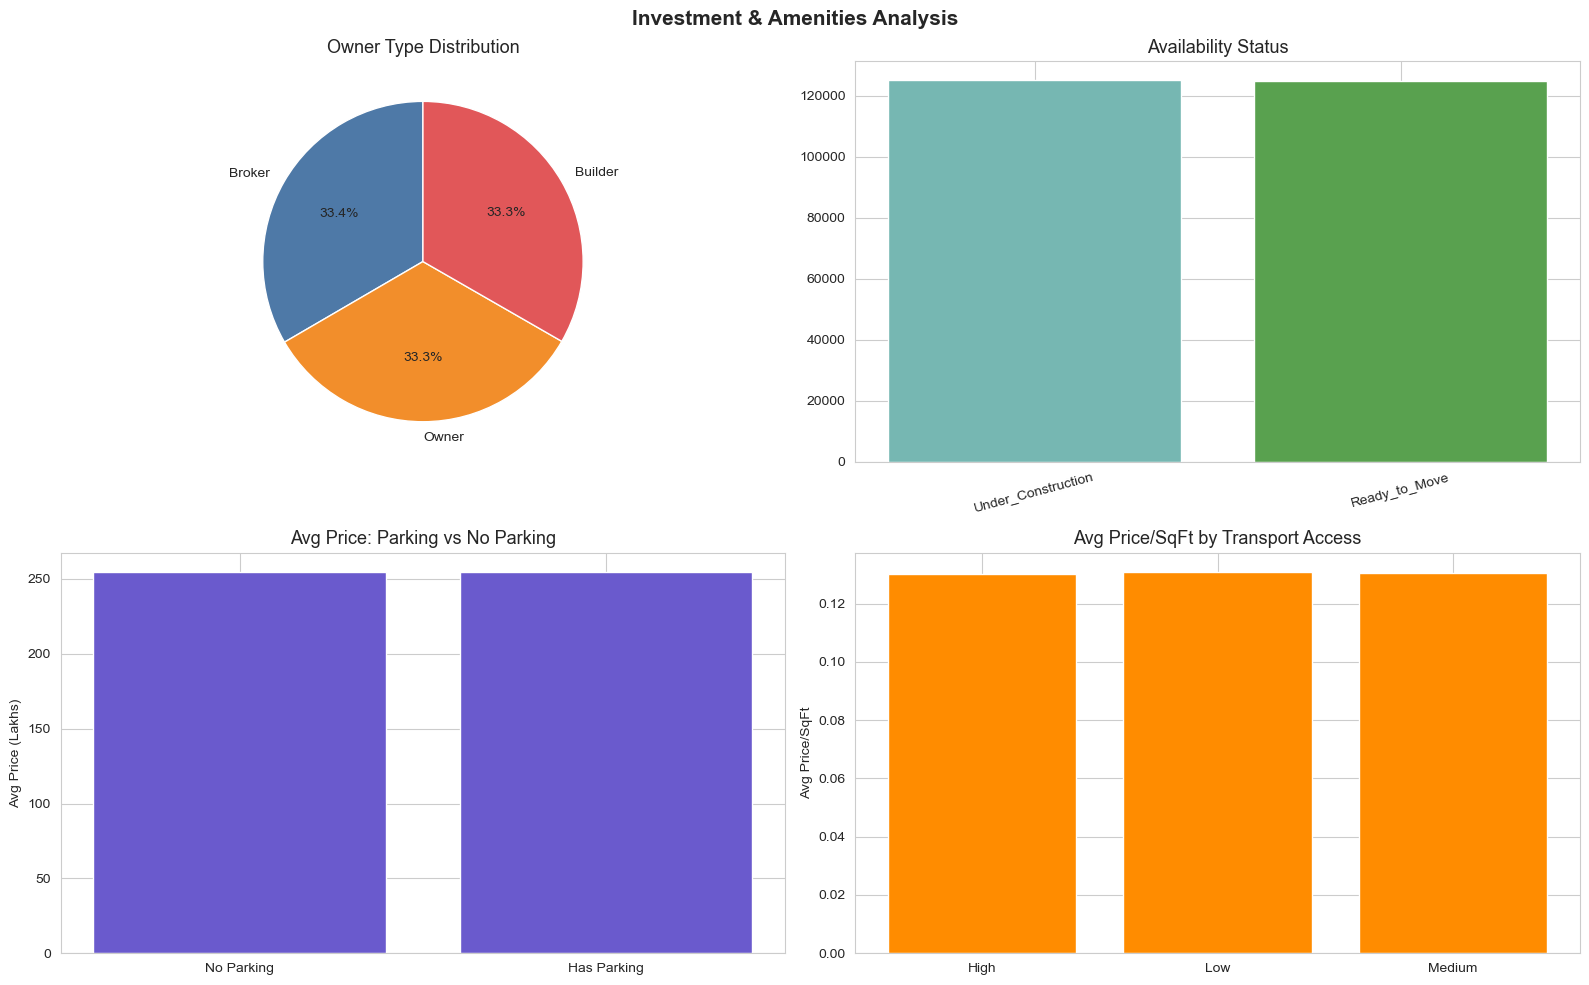

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Investment & Amenities Analysis', fontsize=15, fontweight='bold')

# Owner type pie
oc = df['Owner_Type'].value_counts()
axes[0,0].pie(oc, labels=oc.index, autopct='%1.1f%%', startangle=90,
              colors=['#4e79a7','#f28e2b','#e15759'])
axes[0,0].set_title('Owner Type Distribution')

# Availability status
av = df['Availability_Status'].value_counts()
axes[0,1].bar(av.index, av.values, color=['#76b7b2','#59a14f','#edc948'])
axes[0,1].set_title('Availability Status')
axes[0,1].tick_params(axis='x', rotation=15)

# Parking vs price
pp = df.groupby('Parking_Space')['Price_in_Lakhs'].mean()
axes[1,0].bar(['No Parking','Has Parking'], pp.values, color='slateblue')
axes[1,0].set_title('Avg Price: Parking vs No Parking')
axes[1,0].set_ylabel('Avg Price (Lakhs)')

# Transport accessibility
tp = df.groupby('Public_Transport_Accessibility')['Calc_Price_per_SqFt'].mean()
axes[1,1].bar(tp.index, tp.values, color='darkorange')
axes[1,1].set_title('Avg Price/SqFt by Transport Access')
axes[1,1].set_ylabel('Avg Price/SqFt')

plt.tight_layout()
plt.show()

### 5.6 Price by Furnished Status

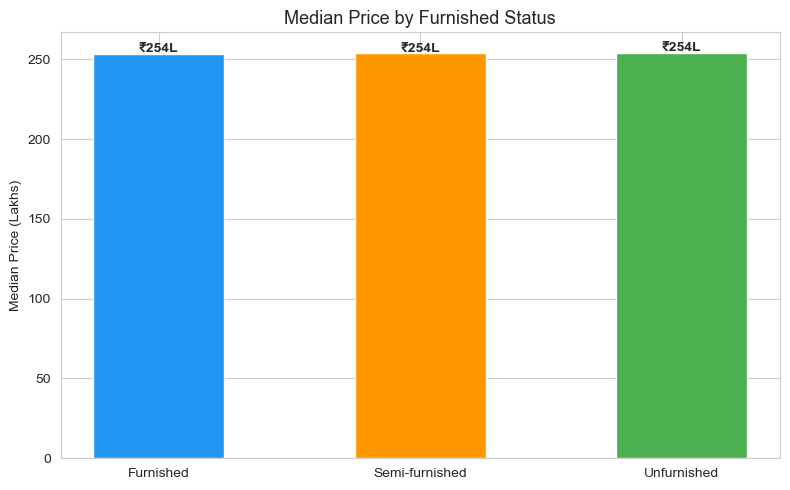

In [13]:
furn = df.groupby('Furnished_Status')['Price_in_Lakhs'].median()
plt.figure(figsize=(8,5))
bars = plt.bar(furn.index, furn.values, color=['#2196F3','#FF9800','#4CAF50'], width=0.5)
for bar, v in zip(bars, furn.values):
    plt.text(bar.get_x() + bar.get_width()/2, v+1, f'₹{v:.0f}L',
             ha='center', fontweight='bold')
plt.title('Median Price by Furnished Status')
plt.ylabel('Median Price (Lakhs)')
plt.tight_layout()
plt.show()

## Step 6: Model Preparation

- Label-encode categorical columns  
- Separate feature sets for Classification vs Regression  
- Sample 50,000 rows for tractable training (representatively sampled)  
- StandardScaler normalisation  
- 80/20 train-test split

In [14]:
cat_cols = ['State','City','Property_Type','Furnished_Status',
            'Facing','Owner_Type','Availability_Status','Public_Transport_Accessibility']

df_model = df.copy()
for col in cat_cols:
    df_model[col] = LabelEncoder().fit_transform(df_model[col].astype(str))

# Classification: include Price_in_Lakhs (property price is known at time of decision)
clf_drop = ['ID','Locality','Amenities','Price_per_SqFt','Good_Investment','Future_Price_5yr']
X_clf = df_model.drop(columns=clf_drop, errors='ignore')
y_clf = df_model['Good_Investment']

# Regression: exclude Price_in_Lakhs (would be leaky since Future = Price * constant)
reg_drop = ['ID','Locality','Amenities','Price_per_SqFt','Price_in_Lakhs',
            'Future_Price_5yr','Good_Investment']
X_reg = df_model.drop(columns=reg_drop, errors='ignore')
y_reg = df_model['Future_Price_5yr']

print(f'Classification features ({X_clf.shape[1]}): {list(X_clf.columns)}')
print(f'\nRegression features ({X_reg.shape[1]}): {list(X_reg.columns)}')

Classification features (23): ['State', 'City', 'Property_Type', 'BHK', 'Size_in_SqFt', 'Price_in_Lakhs', 'Year_Built', 'Furnished_Status', 'Floor_No', 'Total_Floors', 'Age_of_Property', 'Nearby_Schools', 'Nearby_Hospitals', 'Public_Transport_Accessibility', 'Parking_Space', 'Security', 'Facing', 'Owner_Type', 'Availability_Status', 'Calc_Price_per_SqFt', 'School_Density_Score', 'Hospital_Density_Score', 'Floor_Ratio']

Regression features (22): ['State', 'City', 'Property_Type', 'BHK', 'Size_in_SqFt', 'Year_Built', 'Furnished_Status', 'Floor_No', 'Total_Floors', 'Age_of_Property', 'Nearby_Schools', 'Nearby_Hospitals', 'Public_Transport_Accessibility', 'Parking_Space', 'Security', 'Facing', 'Owner_Type', 'Availability_Status', 'Calc_Price_per_SqFt', 'School_Density_Score', 'Hospital_Density_Score', 'Floor_Ratio']


In [15]:
# Sample 50k rows for speed (dataset has 250k)
rng = np.random.default_rng(42)
idx = rng.choice(len(df_model), size=50000, replace=False)

Xc_s, yc_s = X_clf.iloc[idx].reset_index(drop=True), y_clf.iloc[idx].reset_index(drop=True)
Xr_s, yr_s = X_reg.iloc[idx].reset_index(drop=True), y_reg.iloc[idx].reset_index(drop=True)

# Scale
sc_clf = StandardScaler()
sc_reg = StandardScaler()
Xc_scaled = pd.DataFrame(sc_clf.fit_transform(Xc_s), columns=Xc_s.columns)
Xr_scaled = pd.DataFrame(sc_reg.fit_transform(Xr_s), columns=Xr_s.columns)

# Train-test split
Xc_tr, Xc_te, yc_tr, yc_te = train_test_split(Xc_scaled, yc_s, test_size=0.2, random_state=42, stratify=yc_s)
Xr_tr, Xr_te, yr_tr, yr_te = train_test_split(Xr_scaled, yr_s, test_size=0.2, random_state=42)

print(f'Classification — Train: {Xc_tr.shape[0]:,} | Test: {Xc_te.shape[0]:,}')
print(f'Regression     — Train: {Xr_tr.shape[0]:,} | Test: {Xr_te.shape[0]:,}')

Classification — Train: 40,000 | Test: 10,000
Regression     — Train: 40,000 | Test: 10,000


## Step 7: Classification — Is this a Good Investment?

Models trained:
- **Random Forest Classifier** (n_estimators=50, max_depth=12)
- **Logistic Regression**

Metrics: Accuracy, F1-Score, Confusion Matrix

In [16]:
# Train models
clf_rf = RandomForestClassifier(n_estimators=50, max_depth=12, n_jobs=-1, random_state=42)
clf_rf.fit(Xc_tr, yc_tr)
yc_pred_rf = clf_rf.predict(Xc_te)

clf_lr = LogisticRegression(max_iter=300, random_state=42)
clf_lr.fit(Xc_tr, yc_tr)
yc_pred_lr = clf_lr.predict(Xc_te)

# Metrics
acc_rf = accuracy_score(yc_te, yc_pred_rf)
f1_rf  = f1_score(yc_te, yc_pred_rf)
acc_lr = accuracy_score(yc_te, yc_pred_lr)
f1_lr  = f1_score(yc_te, yc_pred_lr)

print('Classification Results')
print('='*45)
print(f'Random Forest  → Accuracy: {acc_rf:.4f} | F1: {f1_rf:.4f}')
print(f'Logistic Reg   → Accuracy: {acc_lr:.4f} | F1: {f1_lr:.4f}')
print(f'\nDetailed RF Report:\n')
print(classification_report(yc_te, yc_pred_rf, target_names=['Not Good','Good Investment']))

Classification Results
Random Forest  → Accuracy: 0.9992 | F1: 0.9993
Logistic Reg   → Accuracy: 0.8737 | F1: 0.8831

Detailed RF Report:

                 precision    recall  f1-score   support

       Not Good       1.00      1.00      1.00      4626
Good Investment       1.00      1.00      1.00      5374

       accuracy                           1.00     10000
      macro avg       1.00      1.00      1.00     10000
   weighted avg       1.00      1.00      1.00     10000



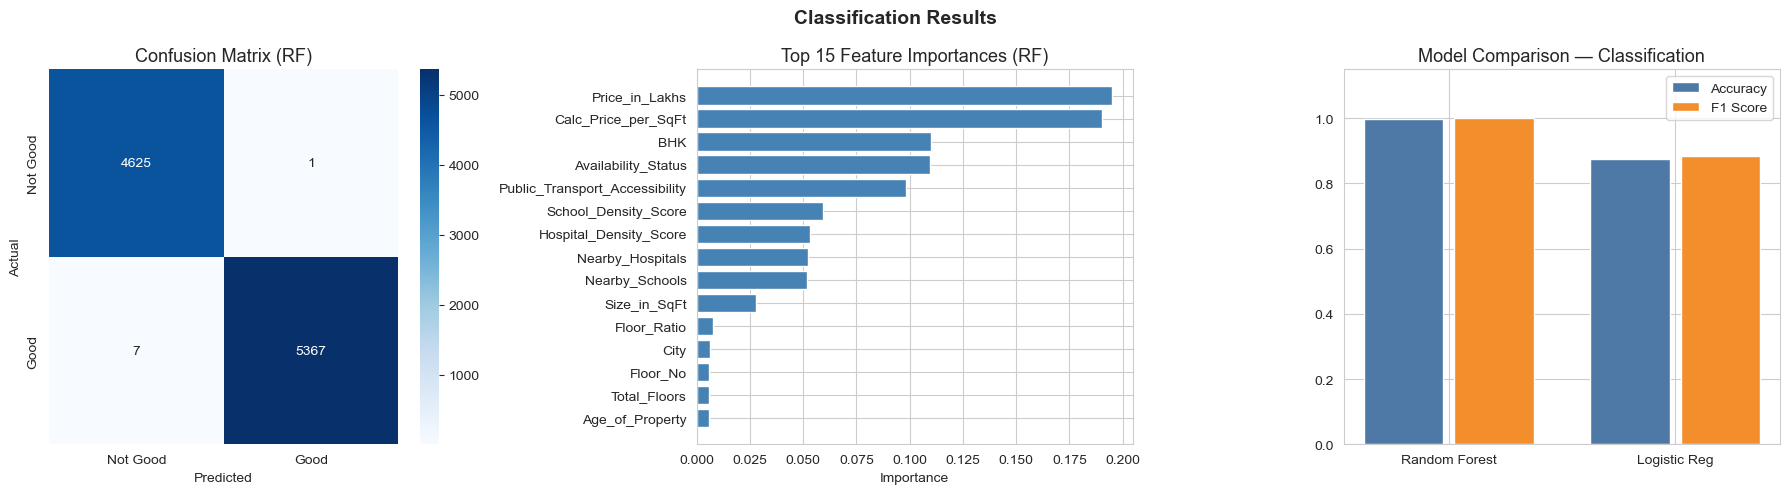

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Classification Results', fontsize=14, fontweight='bold')

# Confusion matrix
cm = confusion_matrix(yc_te, yc_pred_rf)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Not Good','Good'], yticklabels=['Not Good','Good'])
axes[0].set_title('Confusion Matrix (RF)')
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Actual')

# Feature importance
fi = pd.Series(clf_rf.feature_importances_, index=Xc_s.columns).sort_values(ascending=False).head(15)
axes[1].barh(fi.index[::-1], fi.values[::-1], color='steelblue')
axes[1].set_title('Top 15 Feature Importances (RF)')
axes[1].set_xlabel('Importance')

# Model comparison
x = np.arange(2)
axes[2].bar(x-0.2, [acc_rf,acc_lr], 0.35, label='Accuracy', color='#4e79a7')
axes[2].bar(x+0.2, [f1_rf,f1_lr],  0.35, label='F1 Score', color='#f28e2b')
axes[2].set_xticks(x); axes[2].set_xticklabels(['Random Forest','Logistic Reg'])
axes[2].set_ylim(0,1.15); axes[2].legend()
axes[2].set_title('Model Comparison — Classification')

plt.tight_layout()
plt.show()

## Step 8: Regression — Predicted Price After 5 Years

Models trained:
- **Random Forest Regressor** (n_estimators=50, max_depth=12)
- **Ridge Regression** (alpha=1.0)

Metrics: RMSE, MAE, R²

> **Note:** `Price_in_Lakhs` is excluded from regression features to avoid data leakage  
> (Future Price = Price × constant, so including it would trivially solve the problem).

In [18]:
# Train models
reg_rf = RandomForestRegressor(n_estimators=50, max_depth=12, n_jobs=-1, random_state=42)
reg_rf.fit(Xr_tr, yr_tr)
yr_pred_rf = reg_rf.predict(Xr_te)

reg_ridge = Ridge(alpha=1.0)
reg_ridge.fit(Xr_tr, yr_tr)
yr_pred_ridge = reg_ridge.predict(Xr_te)

def reg_report(yt, yp, name):
    rmse = np.sqrt(mean_squared_error(yt, yp))
    mae  = mean_absolute_error(yt, yp)
    r2   = r2_score(yt, yp)
    print(f'{name} → RMSE: {rmse:.2f} Lakhs | MAE: {mae:.2f} Lakhs | R²: {r2:.4f}')
    return rmse, mae, r2

print('Regression Results')
print('='*55)
rmse_rf, mae_rf, r2_rf   = reg_report(yr_te, yr_pred_rf,    'Random Forest   ')
rmse_ri, mae_ri, r2_ri   = reg_report(yr_te, yr_pred_ridge, 'Ridge Regression')

Regression Results
Random Forest    → RMSE: 3.37 Lakhs | MAE: 1.99 Lakhs | R²: 0.9997
Ridge Regression → RMSE: 145.48 Lakhs | MAE: 117.15 Lakhs | R²: 0.5036


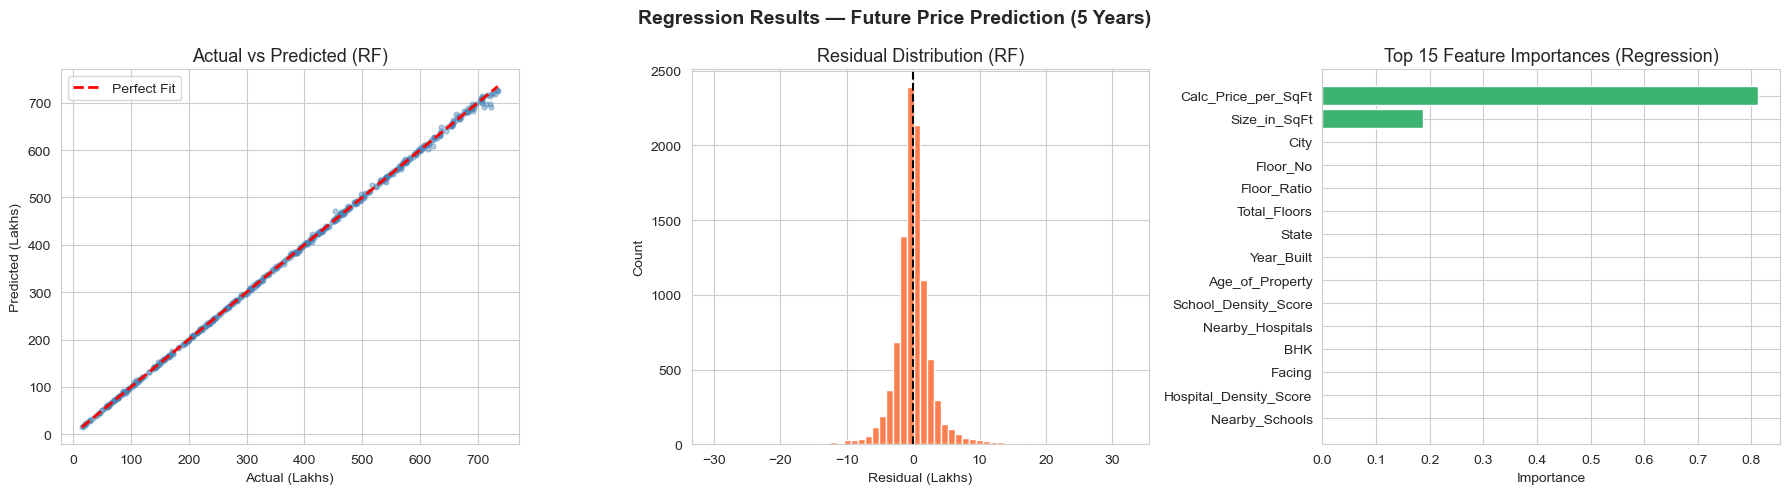

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Regression Results — Future Price Prediction (5 Years)', fontsize=14, fontweight='bold')

# Actual vs Predicted
axes[0].scatter(yr_te[:500], yr_pred_rf[:500], alpha=0.4, s=12, color='steelblue')
mn, mx = yr_te.min(), yr_te.max()
axes[0].plot([mn,mx],[mn,mx],'r--',lw=2, label='Perfect Fit')
axes[0].set_title('Actual vs Predicted (RF)')
axes[0].set_xlabel('Actual (Lakhs)'); axes[0].set_ylabel('Predicted (Lakhs)')
axes[0].legend()

# Residuals
residuals = yr_te.values - yr_pred_rf
axes[1].hist(residuals, bins=60, color='coral', edgecolor='white')
axes[1].axvline(0, color='black', linestyle='--')
axes[1].set_title('Residual Distribution (RF)')
axes[1].set_xlabel('Residual (Lakhs)'); axes[1].set_ylabel('Count')

# Feature importance
fi_r = pd.Series(reg_rf.feature_importances_, index=Xr_s.columns).sort_values(ascending=False).head(15)
axes[2].barh(fi_r.index[::-1], fi_r.values[::-1], color='mediumseagreen')
axes[2].set_title('Top 15 Feature Importances (Regression)')
axes[2].set_xlabel('Importance')

plt.tight_layout()
plt.show()

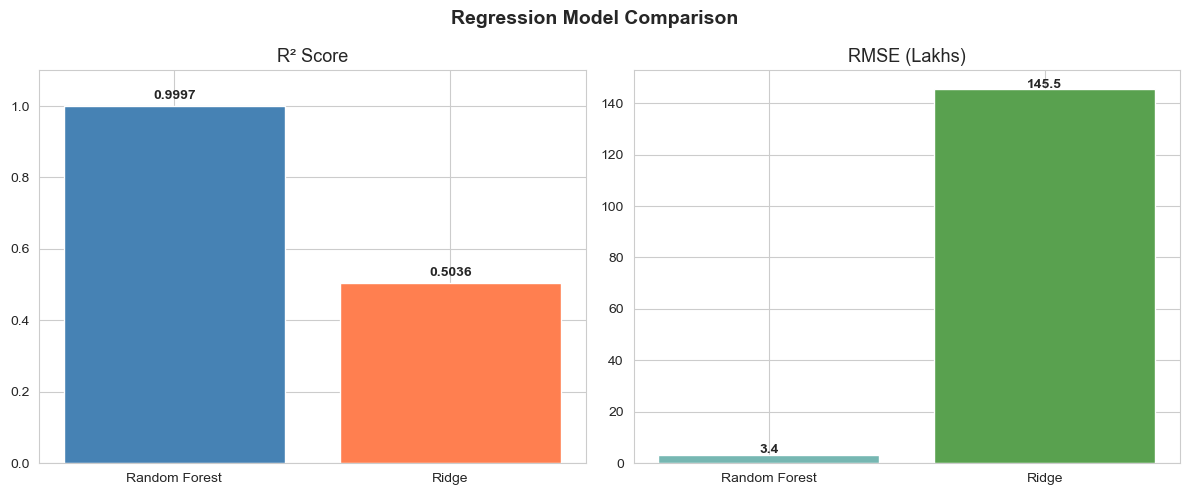

In [20]:
# Model comparison bar chart
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Regression Model Comparison', fontsize=14, fontweight='bold')

bars = axes[0].bar(['Random Forest','Ridge'], [r2_rf, r2_ri], color=['steelblue','coral'])
axes[0].set_title('R² Score'); axes[0].set_ylim(0,1.1)
for b,v in zip(bars,[r2_rf,r2_ri]):
    axes[0].text(b.get_x()+b.get_width()/2, v+0.02, f'{v:.4f}', ha='center', fontweight='bold')

bars2 = axes[1].bar(['Random Forest','Ridge'], [rmse_rf, rmse_ri], color=['#76b7b2','#59a14f'])
axes[1].set_title('RMSE (Lakhs)')
for b,v in zip(bars2,[rmse_rf,rmse_ri]):
    axes[1].text(b.get_x()+b.get_width()/2, v+0.5, f'{v:.1f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

## Step 9: Sample Predictions

In [21]:
# Show sample prediction comparison
sample_df = Xr_te.head(10).copy()
actual_future   = yr_te.head(10).values
predicted_future = reg_rf.predict(sample_df)

sample_clf = Xc_te.head(10).copy()
good_inv_pred = clf_rf.predict(sample_clf)
good_inv_prob = clf_rf.predict_proba(sample_clf)[:,1]

results = pd.DataFrame({
    'Actual_Future_Price': actual_future.round(2),
    'Predicted_Future_Price': predicted_future.round(2),
    'Good_Investment': good_inv_pred,
    'Confidence_%': (good_inv_prob * 100).round(1)
})
print('Sample Predictions (first 10 test rows)')
print('='*65)
results

Sample Predictions (first 10 test rows)


,Actual_Future_Price,Predicted_Future_Price,Good_Investment,Confidence_%
0,416.72,415.39,1,99.9
1,164.93,165.26,1,98.4
2,234.30,234.54,1,100.0
3,90.60,87.83,1,84.2
4,113.53,113.86,1,85.4
5,86.90,91.24,0,14.2
6,720.65,715.10,0,0.4
7,398.23,398.27,1,80.5
8,440.83,438.72,0,1.0
9,364.44,360.28,0,26.4


## Step 10: Final Summary

In [22]:
print('=' * 60)
print('REAL ESTATE INVESTMENT ADVISOR — FINAL RESULTS')
print('=' * 60)
print(f'\nDataset         : {df.shape[0]:,} properties | {df.shape[1]} features')
print(f'Good Investments: {df["Good_Investment"].sum():,} ({df["Good_Investment"].mean()*100:.1f}%)')
print(f'Avg Future Price: ₹{df["Future_Price_5yr"].mean():.1f} Lakhs (8% pa × 5 yrs)')
print()
print('CLASSIFICATION (Good Investment Prediction)')
print('-' * 45)
print(f'  Random Forest  → Accuracy: {acc_rf:.4f} | F1: {f1_rf:.4f}')
print(f'  Logistic Reg   → Accuracy: {acc_lr:.4f} | F1: {f1_lr:.4f}')
print()
print('REGRESSION (Future Price 5-Year Prediction)')
print('-' * 45)
print(f'  Random Forest  → RMSE: {rmse_rf:.2f}L | MAE: {mae_rf:.2f}L | R²: {r2_rf:.4f}')
print(f'  Ridge Reg      → RMSE: {rmse_ri:.2f}L | MAE: {mae_ri:.2f}L | R²: {r2_ri:.4f}')
print()
print('Best Models: Random Forest (both tasks) ✓')

REAL ESTATE INVESTMENT ADVISOR — FINAL RESULTS

Dataset         : 250,000 properties | 29 features
Good Investments: 134,349 (53.7%)
Avg Future Price: ₹374.1 Lakhs (8% pa × 5 yrs)

CLASSIFICATION (Good Investment Prediction)
---------------------------------------------
  Random Forest  → Accuracy: 0.9992 | F1: 0.9993
  Logistic Reg   → Accuracy: 0.8737 | F1: 0.8831

REGRESSION (Future Price 5-Year Prediction)
---------------------------------------------
  Random Forest  → RMSE: 3.37L | MAE: 1.99L | R²: 0.9997
  Ridge Reg      → RMSE: 145.48L | MAE: 117.15L | R²: 0.5036

Best Models: Random Forest (both tasks) ✓
